# Étude de cas — Optimisation de portefeuille de Markowitz avec contrainte de cardinalité
## Application des EDA à la finance quantitative

**Présenté par :** Achraf Zahid & Mohamed Amine Arbani  
**Encadré par :** M. Abderrahim Azouani

---

## 1. Problématique

Soit un univers de $N$ actifs caractérisés par un vecteur de rendements espérés $\mu \in \mathbb{R}^N$ et une matrice de covariance $\Sigma \in \mathbb{R}^{N \times N}$. On cherche les poids $w$ d'un portefeuille qui résolvent :

$$\max_{w \in \mathbb{R}^N} \; w^\top \mu - \lambda \cdot w^\top \Sigma w$$

$$\text{s.c.} \quad \sum_{i=1}^N w_i = 1, \qquad w_i \ge 0, \qquad \|w\|_0 \le K$$

- $w^\top \mu$ : rendement espéré du portefeuille
- $w^\top \Sigma w$ : variance (risque) du portefeuille
- $\lambda > 0$ : coefficient d'aversion au risque
- $\|w\|_0 \le K$ : **au plus $K$ actifs avec un poids non nul** (contrainte de cardinalité)

### Pourquoi c'est difficile

La contrainte $\|w\|_0 \le K$ rend le problème **NP-difficile**. La sélection des $K$ actifs (combinatoire, $\binom{N}{K}$ possibilités) et leur pondération (continue, sur le simplexe) sont couplées.

### Approche : EDA hybride

- **Boucle externe (discret) :** un EDA univarié (UMDA) qui apprend la probabilité d'inclusion de chaque actif dans les meilleurs portefeuilles.
- **Boucle interne (continu) :** un EDA gaussien (EMNA) qui optimise les poids sur le sous-univers sélectionné.

À chaque génération externe, on évalue la qualité d'une sélection en optimisant rapidement les poids correspondants.

## 2. Imports et configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.optimize import minimize

np.random.seed(42)
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 3. Génération des données

On simule un univers de **60 actifs répartis en 6 secteurs** (10 actifs par secteur). Les rendements suivent un modèle factoriel sectoriel :

$$r_{i,t} = \beta_i \cdot f_{s(i),t} + \varepsilon_{i,t}$$

où $f_{s,t}$ est le facteur de rendement du secteur $s$ et $\varepsilon_{i,t}$ un bruit idiosyncratique. Cette structure crée naturellement des **grappes de corrélation sectorielle**.

> Les tickers sont réels mais les rendements sont **simulés** pour la démonstration.

In [2]:
sectors_def = {
    'Tech':        ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'META', 'NVDA', 'TSLA', 'ORCL', 'INTC', 'AMD'],
    'Financials':  ['JPM', 'BAC', 'WFC', 'GS', 'MS', 'C', 'BLK', 'AXP', 'SCHW', 'USB'],
    'Energy':      ['XOM', 'CVX', 'COP', 'SLB', 'EOG', 'PSX', 'MPC', 'VLO', 'OKE', 'KMI'],
    'Healthcare':  ['JNJ', 'PFE', 'UNH', 'ABT', 'MRK', 'TMO', 'LLY', 'ABBV', 'BMY', 'MDT'],
    'Consumer':    ['WMT', 'HD', 'COST', 'MCD', 'NKE', 'SBUX', 'TGT', 'LOW', 'BKNG', 'CMG'],
    'Industrials': ['BA', 'CAT', 'UNP', 'HON', 'GE', 'LMT', 'MMM', 'RTX', 'DE', 'FDX'],
}

tickers = [t for s in sectors_def.values() for t in s]
N = len(tickers)
sector_of = {t: s for s, ts in sectors_def.items() for t in ts}
sector_names = list(sectors_def)
sector_idx = np.array([sector_names.index(sector_of[t]) for t in tickers])
N_SECTORS = len(sector_names)

# Paramètres sectoriels (annualisés)
mu_sect_annual = np.array([0.18, 0.10, 0.08, 0.12, 0.09, 0.10])
vol_sect_annual = np.array([0.30, 0.22, 0.35, 0.18, 0.20, 0.24])

T = 1000  # ~4 années de trading
mu_sect_d = mu_sect_annual / 252
vol_sect_d = vol_sect_annual / np.sqrt(252)

factors = np.random.randn(T, N_SECTORS) * vol_sect_d + mu_sect_d
betas = np.random.uniform(0.6, 1.4, N)
idio_vol_d = np.random.uniform(0.005, 0.012, N)

returns = np.zeros((T, N))
for i in range(N):
    returns[:, i] = betas[i] * factors[:, sector_idx[i]] + np.random.randn(T) * idio_vol_d[i]

mu = returns.mean(axis=0) * 252
Sigma = np.cov(returns.T) * 252
vol = np.sqrt(np.diag(Sigma))

df_assets = pd.DataFrame({
    'Ticker': tickers,
    'Secteur': [sector_of[t] for t in tickers],
    'Rendement annuel': mu,
    'Volatilite annuelle': vol,
    'Sharpe': mu / vol,
})
print(f"Univers : {N} actifs x {N_SECTORS} secteurs x {T} jours\n")
print(df_assets.head(10).to_string(index=False))

Univers : 60 actifs x 6 secteurs x 1000 jours

Ticker Secteur  Rendement annuel  Volatilite annuelle   Sharpe
  AAPL    Tech          0.119938             0.318228 0.376893
  MSFT    Tech          0.193046             0.253875 0.760398
  GOOG    Tech          0.281586             0.294207 0.957100
  AMZN    Tech          0.144537             0.256906 0.562606
  META    Tech          0.214723             0.418093 0.513577
  NVDA    Tech          0.226476             0.300306 0.754151
  TSLA    Tech          0.230827             0.261288 0.883418
  ORCL    Tech          0.323287             0.316879 1.020224
  INTC    Tech          0.267934             0.308060 0.869744
   AMD    Tech          0.310581             0.391606 0.793095


## 4. Analyse exploratoire

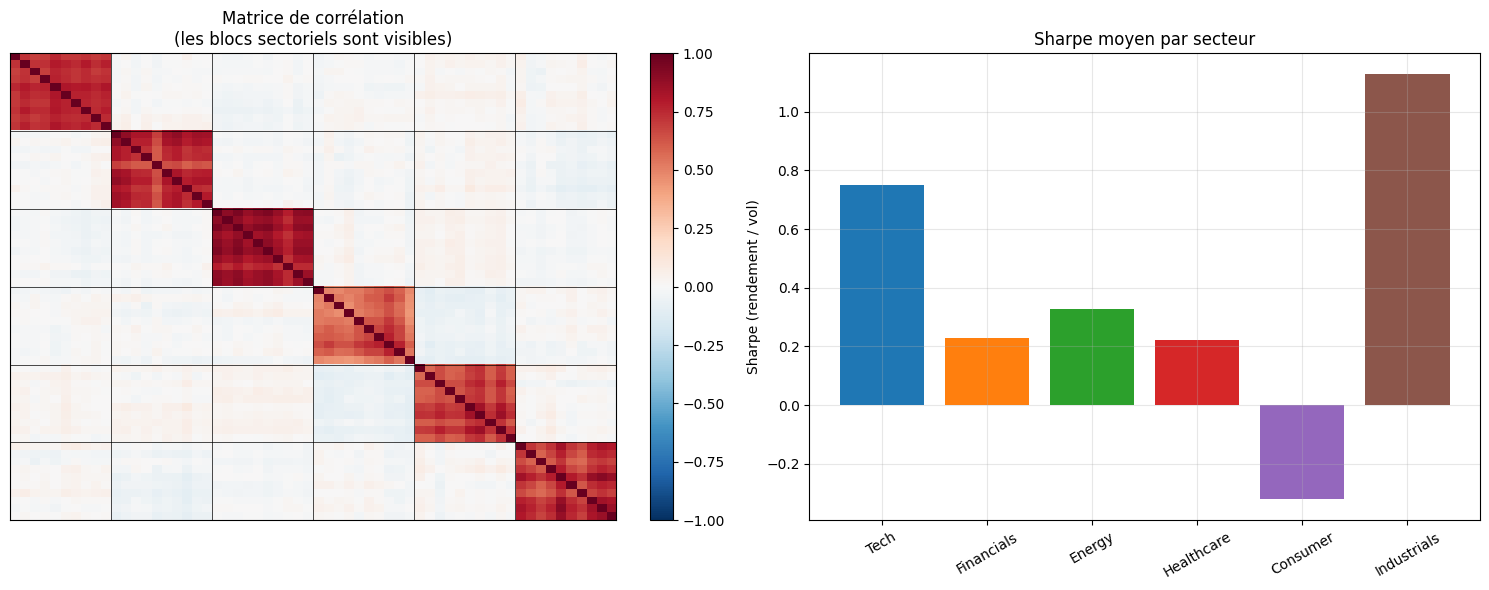

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

corr = np.corrcoef(returns.T)
im = axes[0].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title("Matrice de corrélation\n(les blocs sectoriels sont visibles)")
axes[0].set_xticks([])
axes[0].set_yticks([])
for k in range(1, N_SECTORS):
    axes[0].axhline(k*10 - 0.5, color='black', lw=0.5)
    axes[0].axvline(k*10 - 0.5, color='black', lw=0.5)
plt.colorbar(im, ax=axes[0], fraction=0.046)

sharpe_by_sector = df_assets.groupby('Secteur')['Sharpe'].mean().reindex(sector_names)
colors_sec = plt.cm.tab10(np.arange(N_SECTORS))
axes[1].bar(sector_names, sharpe_by_sector.values, color=colors_sec)
axes[1].set_title("Sharpe moyen par secteur")
axes[1].set_ylabel("Sharpe (rendement / vol)")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Observation.** La matrice de corrélation montre clairement les 6 blocs sectoriels. C'est la structure que les EDA multivariés (ECGA, BOA) sont capables d'apprendre automatiquement.

Tech et Healthcare offrent les meilleurs Sharpe ; Energy est pénalisé par sa volatilité élevée.

## 5. Stratégies de référence

1. **Portefeuille équipondéré** sur les $K$ actifs au meilleur Sharpe individuel.
2. **Markowitz analytique long-only** sans contrainte de cardinalité.

In [4]:
LAMBDA = 2.0
K = 30

def portfolio_metrics(w, mu, Sigma):
    ret = w @ mu
    v = np.sqrt(w @ Sigma @ w)
    return ret, v, ret / v if v > 0 else 0.0

def utility(w, mu, Sigma, lam):
    return w @ mu - lam * w @ Sigma @ w

def solve_markowitz_long_only(mu_sub, Sigma_sub, lam):
    """max w'mu - lam w'Sigma w, sum(w)=1, w>=0 via SLSQP."""
    k = len(mu_sub)
    neg_obj = lambda w: -(w @ mu_sub - lam * w @ Sigma_sub @ w)
    cons = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    bnds = [(0, 1)] * k
    w0 = np.ones(k) / k
    res = minimize(neg_obj, w0, method='SLSQP', constraints=cons, bounds=bnds,
                   options={'maxiter': 200, 'ftol': 1e-9})
    return res.x, -res.fun

# Baseline 1 : équipondéré top-K Sharpe
top_K_sharpe = np.argsort(mu / vol)[-K:]
w_eq = np.zeros(N)
w_eq[top_K_sharpe] = 1.0 / K
ret_eq, vol_eq, sharpe_eq = portfolio_metrics(w_eq, mu, Sigma)

# Baseline 2 : Markowitz long-only sans cardinalité
w_mv_full, _ = solve_markowitz_long_only(mu, Sigma, LAMBDA)
ret_mv, vol_mv, sharpe_mv = portfolio_metrics(w_mv_full, mu, Sigma)
n_active_mv = int((w_mv_full > 1e-4).sum())

print(f"Baseline 1 - Equipondere (K={K}, top Sharpe)")
print(f"  Rendement={ret_eq:.4f} | Vol={vol_eq:.4f} | Sharpe={sharpe_eq:.4f}")
print(f"\nBaseline 2 - Markowitz long-only (sans cardinalite)")
print(f"  Rendement={ret_mv:.4f} | Vol={vol_mv:.4f} | Sharpe={sharpe_mv:.4f}")
print(f"  Nombre d'actifs actifs : {n_active_mv} (sur {N})")

Baseline 1 - Equipondere (K=30, top Sharpe)
  Rendement=0.2363 | Vol=0.1434 | Sharpe=1.6478

Baseline 2 - Markowitz long-only (sans cardinalite)
  Rendement=0.3718 | Vol=0.2069 | Sharpe=1.7972
  Nombre d'actifs actifs : 5 (sur 60)


## 6. Boucle interne — EMNA pour les poids continus

**Estimation of Multivariate Normal Algorithm.** Étant donnée une sélection de $K$ actifs, on cherche les poids optimaux. EMNA modélise la distribution des bons poids par une gaussienne $\mathcal{N}(\boldsymbol\mu_w, \boldsymbol\Sigma_w)$ mise à jour à chaque génération.

1. Échantillonner $n_{\text{pop}}$ vecteurs depuis $\mathcal{N}(\boldsymbol\mu_w, \boldsymbol\Sigma_w)$.
2. **Projeter** sur le simplexe $\{w : \sum w_i = 1, w \ge 0\}$.
3. Évaluer l'utilité, garder les meilleurs.
4. Ré-estimer $(\boldsymbol\mu_w, \boldsymbol\Sigma_w)$.

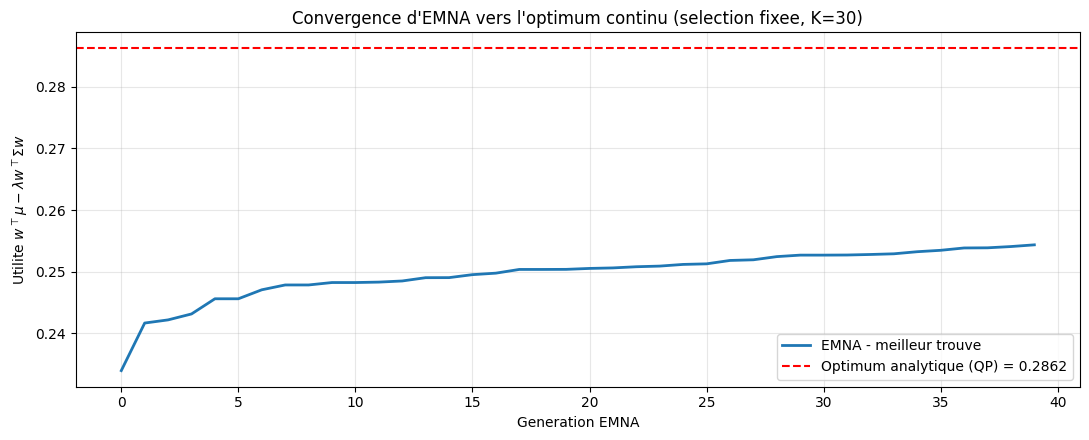


Utilite EMNA  : 0.254356
Utilite QP    : 0.286228
Ecart relatif : 11.135%


In [5]:
def project_simplex(v):
    """Projection sur le simplexe unitaire long-only."""
    n = len(v)
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u) - 1.0
    rho = np.where(u - cssv / (np.arange(n) + 1) > 0)[0][-1]
    theta = cssv[rho] / (rho + 1)
    return np.maximum(v - theta, 0.0)

def emna_weights(mu_sub, Sigma_sub, lam, n_pop=40, n_gen=30, tau=0.4, track=False):
    """EMNA sur le simplexe."""
    k = len(mu_sub)
    m = np.ones(k) / k
    C = np.eye(k) * 0.05
    history = []
    best_w, best_f = m.copy(), utility(m, mu_sub, Sigma_sub, lam)
    for g in range(n_gen):
        samples = np.random.multivariate_normal(m, C, size=n_pop)
        samples = np.array([project_simplex(s) for s in samples])
        fitness = np.array([utility(s, mu_sub, Sigma_sub, lam) for s in samples])
        i_best = np.argmax(fitness)
        if fitness[i_best] > best_f:
            best_f = fitness[i_best]
            best_w = samples[i_best].copy()
        n_top = max(2, int(tau * n_pop))
        top_idx = np.argsort(fitness)[-n_top:]
        top = samples[top_idx]
        m = top.mean(axis=0)
        C = np.cov(top.T) + np.eye(k) * 1e-6
        if track:
            history.append(best_f)
    return best_w, best_f, history

# Demonstration : EMNA sur les 30 meilleurs Sharpe
sel_demo = top_K_sharpe
mu_demo = mu[sel_demo]
Sigma_demo = Sigma[np.ix_(sel_demo, sel_demo)]

w_emna, util_emna, hist_emna = emna_weights(mu_demo, Sigma_demo, LAMBDA, n_gen=40, track=True)
w_qp, util_qp = solve_markowitz_long_only(mu_demo, Sigma_demo, LAMBDA)

plt.figure(figsize=(11, 4.5))
plt.plot(hist_emna, lw=2, label='EMNA - meilleur trouve')
plt.axhline(util_qp, color='red', linestyle='--', lw=1.5,
            label=f'Optimum analytique (QP) = {util_qp:.4f}')
plt.xlabel("Generation EMNA")
plt.ylabel(r"Utilite $w^\top \mu - \lambda w^\top \Sigma w$")
plt.title("Convergence d'EMNA vers l'optimum continu (selection fixee, K=30)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nUtilite EMNA  : {util_emna:.6f}")
print(f"Utilite QP    : {util_qp:.6f}")
print(f"Ecart relatif : {(util_qp - util_emna) / abs(util_qp) * 100:.3f}%")

**Observation.** EMNA converge vers l'optimum analytique en quelques dizaines de générations. C'est la version continue du paradigme EDA.

> Dans la suite, on utilisera le solveur QP pour la boucle interne (plus rapide). EMNA reste pertinent quand le sous-problème est lui-même non convexe (coûts de transaction non linéaires, contraintes complexes).

## 7. Boucle externe — UMDA pour la sélection

**Univariate Marginal Distribution Algorithm.** On maintient $\boldsymbol\theta \in [0,1]^N$ où $\theta_i$ est la probabilité que l'actif $i$ soit inclus dans un bon portefeuille.

1. **Échantillonner** $n_{\text{pop}}$ portefeuilles de $K$ actifs, sans remplacement, pondérés par $\boldsymbol\theta$.
2. **Évaluer** chaque portefeuille en optimisant ses poids (QP interne).
3. **Sélectionner** les $\tau \cdot n_{\text{pop}}$ meilleurs.
4. **Mettre à jour** $\theta_i$ par fréquence d'apparition dans les meilleurs.

In [ ]:
def umda_cardinality(mu, Sigma, K, lam, n_pop=40, n_gen=1000, tau=0.4, smooth=0.5, verbose=True):
    """UMDA pour selection avec cardinalite fixe K."""
    N = len(mu)
    theta = np.ones(N) * K / N

    history = {'best_fitness': [], 'theta': []}
    best_f, best_sel, best_w_full = -np.inf, None, None

    for g in range(n_gen):
        # 1. Echantillonnage de n_pop portefeuilles
        portfolios = []
        for _ in range(n_pop):
            probs = theta / theta.sum()
            sel = np.random.choice(N, size=K, replace=False, p=probs)
            portfolios.append(sel)

        # 2. Evaluation : QP pour chaque
        fitness = np.empty(n_pop)
        all_w = []
        for j, sel in enumerate(portfolios):
            mu_s = mu[sel]
            S_s = Sigma[np.ix_(sel, sel)]
            try:
                w_s, util = solve_markowitz_long_only(mu_s, S_s, lam)
            except Exception:
                w_s, util = np.ones(K)/K, -1e9
            fitness[j] = util
            all_w.append(w_s)

        i_best = np.argmax(fitness)
        if fitness[i_best] > best_f:
            best_f = fitness[i_best]
            best_sel = portfolios[i_best].copy()
            best_w_full = np.zeros(N)
            best_w_full[best_sel] = all_w[i_best]

        # 3-4. Selection top tau et mise a jour theta
        n_top = max(2, int(tau * n_pop))
        top_idx = np.argsort(fitness)[-n_top:]
        theta_emp = np.zeros(N)
        for idx in top_idx:
            theta_emp[portfolios[idx]] += 1
        theta_emp /= n_top
        theta = (1 - smooth) * theta + smooth * theta_emp
        theta = np.clip(theta, 0.01, 0.99)

        history['best_fitness'].append(best_f)
        history['theta'].append(theta.copy())

        if verbose and (g % 100 == 0 or g == n_gen - 1):
            print(f"  Gen {g+1:2d}/{n_gen} | meilleure utilite = {best_f:.5f}")

    history['theta'] = np.array(history['theta'])
    history['best_selection'] = best_sel
    history['best_weights'] = best_w_full
    return best_w_full, best_sel, history

print(f"Lancement de l'EDA hybride avec K={K}, lambda={LAMBDA}...\n")
w_eda, sel_eda, hist = umda_cardinality(mu, Sigma, K, LAMBDA, n_pop=40, n_gen=25)
ret_eda, vol_eda, sharpe_eda = portfolio_metrics(w_eda, mu, Sigma)
n_active_eda = int((w_eda > 1e-4).sum())
print(f"\n=== Resultat EDA ===")
print(f"Rendement={ret_eda:.4f} | Vol={vol_eda:.4f} | Sharpe={sharpe_eda:.4f}")
print(f"Nombre d'actifs actifs : {n_active_eda} (contrainte K={K})")

Lancement de l'EDA hybride avec K=30, lambda=2.0...

  Gen  1/25 | meilleure utilite = 0.28623
  Gen  6/25 | meilleure utilite = 0.28623
  Gen 11/25 | meilleure utilite = 0.28623
  Gen 16/25 | meilleure utilite = 0.28623
  Gen 21/25 | meilleure utilite = 0.28623
  Gen 25/25 | meilleure utilite = 0.28623

=== Resultat EDA ===
Rendement=0.3718 | Vol=0.2069 | Sharpe=1.7972
Nombre d'actifs actifs : 5 (contrainte K=30)


## 8. Visualisation des résultats

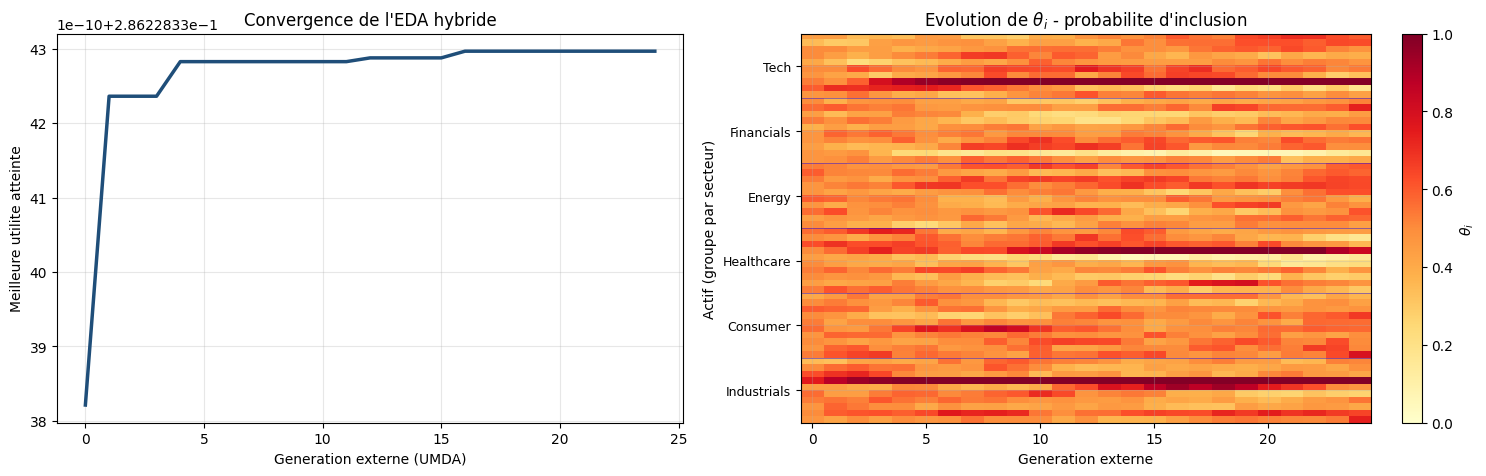

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(hist['best_fitness'], lw=2.5, color='#1f4e79')
axes[0].set_xlabel("Generation externe (UMDA)")
axes[0].set_ylabel("Meilleure utilite atteinte")
axes[0].set_title("Convergence de l'EDA hybride")

theta_matrix = hist['theta'].T
im = axes[1].imshow(theta_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
axes[1].set_xlabel("Generation externe")
axes[1].set_ylabel("Actif (groupe par secteur)")
axes[1].set_title(r"Evolution de $\theta_i$ - probabilite d'inclusion")
for k in range(1, N_SECTORS):
    axes[1].axhline(k*10 - 0.5, color='blue', lw=0.6, alpha=0.5)
axes[1].set_yticks([k*10 + 4.5 for k in range(N_SECTORS)])
axes[1].set_yticklabels(sector_names, fontsize=9)
plt.colorbar(im, ax=axes[1], fraction=0.04, label=r"$\theta_i$")

plt.tight_layout()
plt.show()

**Lecture.** À gauche, l'utilité croît rapidement puis se stabilise. À droite, on voit que certains actifs voient leur $\theta_i$ monter (foncé) tandis que d'autres restent ignorés. L'EDA a appris quelles régions de l'univers méritent d'être explorées.

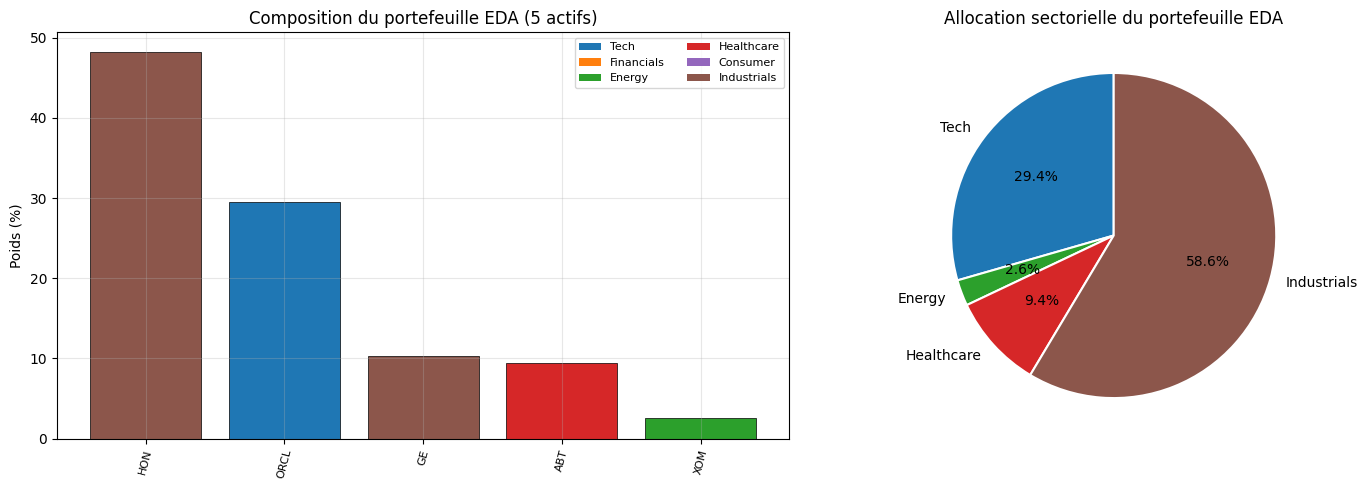

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

active_idx = np.where(w_eda > 1e-4)[0]
active_sorted = active_idx[np.argsort(w_eda[active_idx])[::-1]]
colors_assets = [colors_sec[sector_idx[i]] for i in active_sorted]
labels = [tickers[i] for i in active_sorted]
weights = w_eda[active_sorted]

axes[0].bar(range(len(weights)), weights * 100, color=colors_assets, edgecolor='black', lw=0.5)
axes[0].set_xticks(range(len(weights)))
axes[0].set_xticklabels(labels, rotation=75, fontsize=8)
axes[0].set_ylabel("Poids (%)")
axes[0].set_title(f"Composition du portefeuille EDA ({len(weights)} actifs)")
handles = [Patch(facecolor=colors_sec[i], label=sector_names[i]) for i in range(N_SECTORS)]
axes[0].legend(handles=handles, loc='upper right', fontsize=8, ncol=2)

sector_weights = np.zeros(N_SECTORS)
for i in range(N):
    sector_weights[sector_idx[i]] += w_eda[i]
mask = sector_weights > 1e-6
axes[1].pie(sector_weights[mask], labels=[sector_names[i] for i in range(N_SECTORS) if mask[i]],
            colors=[colors_sec[i] for i in range(N_SECTORS) if mask[i]],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title("Allocation sectorielle du portefeuille EDA")

plt.tight_layout()
plt.show()

## 9. Comparaison des trois stratégies

In [9]:
results = pd.DataFrame({
    'Strategie': ['Equipondere (top-K Sharpe)', 'Markowitz long-only (sans card.)', 'EDA hybride (K=30)'],
    'Rendement': [ret_eq, ret_mv, ret_eda],
    'Volatilite': [vol_eq, vol_mv, vol_eda],
    'Sharpe': [sharpe_eq, sharpe_mv, sharpe_eda],
    'Utilite': [utility(w_eq, mu, Sigma, LAMBDA),
                utility(w_mv_full, mu, Sigma, LAMBDA),
                utility(w_eda, mu, Sigma, LAMBDA)],
    'Nb actifs': [int((w_eq > 1e-4).sum()), n_active_mv, n_active_eda],
})
print(results.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

                       Strategie  Rendement  Volatilite  Sharpe  Utilite  Nb actifs
      Equipondere (top-K Sharpe)     0.2363      0.1434  1.6478   0.1952         30
Markowitz long-only (sans card.)     0.3718      0.2069  1.7972   0.2862          5
              EDA hybride (K=30)     0.3718      0.2069  1.7972   0.2862          5


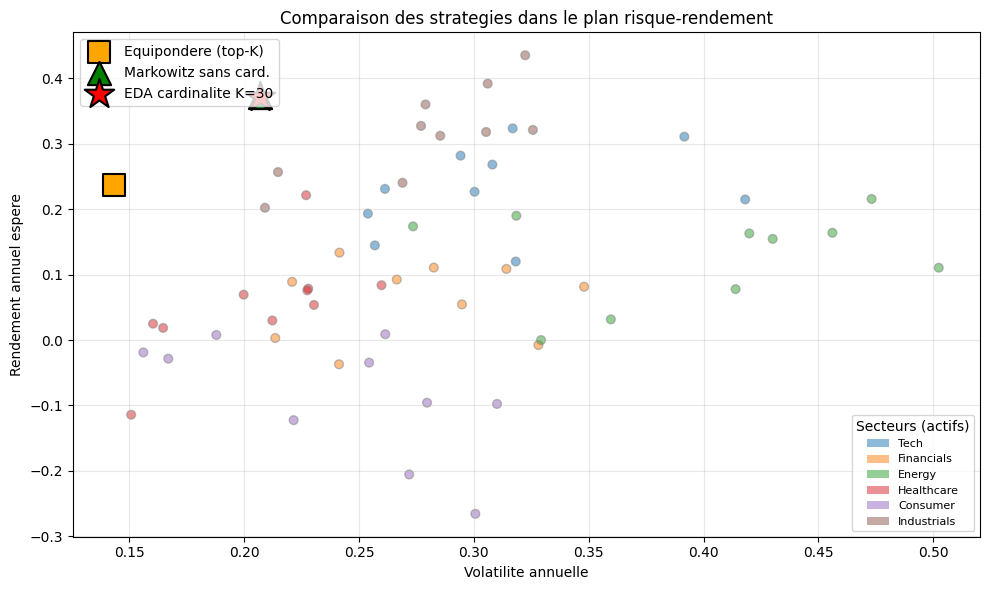

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(vol, mu, c=[colors_sec[s] for s in sector_idx], s=40, alpha=0.5, edgecolor='gray')

strategies = [
    ('Equipondere (top-K)', vol_eq, ret_eq, 'orange', 's', 250),
    ('Markowitz sans card.', vol_mv, ret_mv, 'green', '^', 280),
    ('EDA cardinalite K=30', vol_eda, ret_eda, 'red', '*', 500),
]
for name, v, r, c, m, sz in strategies:
    ax.scatter(v, r, c=c, marker=m, s=sz, label=name, edgecolor='black', lw=1.5, zorder=5)

ax.set_xlabel("Volatilite annuelle")
ax.set_ylabel("Rendement annuel espere")
ax.set_title("Comparaison des strategies dans le plan risque-rendement")

handles_sec = [Patch(facecolor=colors_sec[i], label=sector_names[i], alpha=0.5) for i in range(N_SECTORS)]
legend1 = ax.legend(handles=handles_sec, title='Secteurs (actifs)', loc='lower right', fontsize=8)
ax.add_artist(legend1)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

## 10. Frontière efficiente sous contrainte de cardinalité

On compare la frontière classique (sans cardinalité) à la frontière obtenue par EDA pour différents $\lambda$.

Calcul des frontieres (environ 30s)...
  lambda=  0.5 | sans card.: vol=0.322 ret=0.435 | EDA K=30: vol=0.322 ret=0.435
  lambda=  1.0 | sans card.: vol=0.260 ret=0.409 | EDA K=30: vol=0.260 ret=0.409
  lambda=  2.0 | sans card.: vol=0.207 ret=0.372 | EDA K=30: vol=0.207 ret=0.372
  lambda=  4.0 | sans card.: vol=0.154 ret=0.318 | EDA K=30: vol=0.154 ret=0.318
  lambda=  8.0 | sans card.: vol=0.124 ret=0.274 | EDA K=30: vol=0.124 ret=0.274
  lambda= 16.0 | sans card.: vol=0.095 ret=0.202 | EDA K=30: vol=0.097 ret=0.205


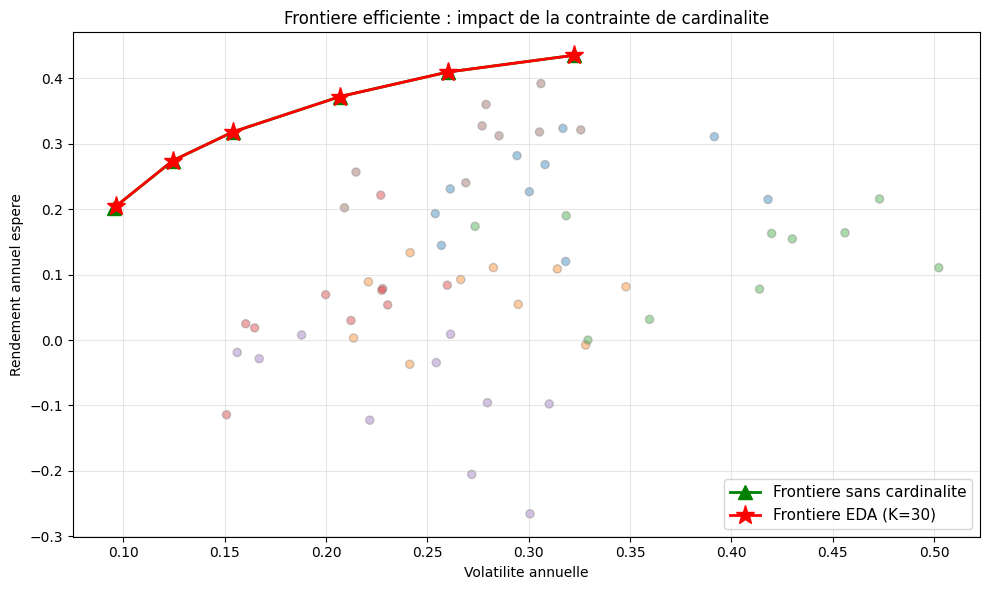

In [11]:
lambdas = [0.5, 1.0, 2.0, 4.0, 8.0, 16.0]

front_unconstr, front_eda = [], []
print("Calcul des frontieres (environ 30s)...")
for lam in lambdas:
    w_u, _ = solve_markowitz_long_only(mu, Sigma, lam)
    r_u, v_u, _ = portfolio_metrics(w_u, mu, Sigma)
    front_unconstr.append((v_u, r_u))
    w_e, _, _ = umda_cardinality(mu, Sigma, K, lam, n_pop=30, n_gen=15, verbose=False)
    r_e, v_e, _ = portfolio_metrics(w_e, mu, Sigma)
    front_eda.append((v_e, r_e))
    print(f"  lambda={lam:5.1f} | sans card.: vol={v_u:.3f} ret={r_u:.3f} | EDA K=30: vol={v_e:.3f} ret={r_e:.3f}")

front_unconstr = np.array(front_unconstr)
front_eda = np.array(front_eda)

plt.figure(figsize=(10, 6))
plt.scatter(vol, mu, c=[colors_sec[s] for s in sector_idx], s=35, alpha=0.4, edgecolor='gray')
plt.plot(front_unconstr[:, 0], front_unconstr[:, 1], 'g-^', lw=2, ms=10, label='Frontiere sans cardinalite')
plt.plot(front_eda[:, 0], front_eda[:, 1], 'r-*', lw=2, ms=14, label=f'Frontiere EDA (K={K})')
plt.xlabel("Volatilite annuelle")
plt.ylabel("Rendement annuel espere")
plt.title("Frontiere efficiente : impact de la contrainte de cardinalite")
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

**Interprétation.** La frontière EDA (rouge) est légèrement en-dessous de la frontière sans contrainte (verte) — c'est le **prix de la cardinalité** : restreindre à 30 actifs au lieu de 60 réduit la diversification optimale.

L'écart reste faible : l'EDA trouve des sélections de 30 actifs presque aussi efficaces que l'allocation complète. En pratique, ce léger sacrifice est compensé par des **coûts de transaction réduits**, une **gestion opérationnelle plus simple** et une **meilleure interprétabilité**.

## 11. Conclusion

### Ce qu'on a fait
- Formulé le problème de Markowitz avec contrainte de cardinalité (NP-difficile).
- Construit un **EDA hybride** :
  - UMDA pour la sélection discrète des $K$ actifs.
  - EMNA (illustré) et solveur QP (utilisé) pour les poids continus.
- Comparé à l'équipondéré et au Markowitz sans contrainte.
- Tracé la frontière efficiente sous contrainte.

### Ce qu'on observe
- L'EDA converge en quelques dizaines de générations.
- Les probabilités $\theta_i$ apprises révèlent **quels actifs sont structurellement importants** — l'algorithme est interprétable.
- L'allocation sectorielle finale est diversifiée.
- L'écart de performance par rapport à la frontière sans cardinalité reste modeste.

### Pistes d'amélioration
- Remplacer UMDA par **ECGA** ou **BOA** pour exploiter explicitement la structure sectorielle.
- Ajouter un **surrogate** (processus gaussien) sur l'utilité pour réduire le nombre de QP.
- Étendre à un cadre **multi-objectif** (MIDEA) pour la frontière de Pareto Sharpe / drawdown.
- Tester en **walk-forward** sur données réelles.

---

*Présenté par Achraf Zahid & Mohamed Amine Arbani — encadré par M. Abderrahim Azouani.*